# CS3807 — Deep Learning Laboratory
## Experiment 1: Single-Layer Perceptron for Binary Classification (Banknote Authenticity)

## 0. Setup

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# --- Font & styling requirements (report-ready figures) -------------------
# Times New Roman, size 13, with bold axis labels and tick labels.
# Colab ships "Liberation Serif" / "Nimbus Roman" as metric-compatible
# fallbacks if "Times New Roman" itself isn't installed, so this is safe
# to run as-is in Colab.
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "Nimbus Roman", "DejaVu Serif"]
plt.rcParams["font.size"] = 13
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 13
# EPS backend cannot render transparency; flatten alpha compositing so
# saved figures don't silently drop or distort translucent elements.
plt.rcParams["savefig.transparent"] = False

def _bold_axes(ax=None):
    # Makes the x/y axis tick labels bold on a given (or current) axes.
    # Axis *labels* are already bold globally via axes.labelweight above;
    # this additionally bolds the numeric/category tick labels themselves.
    target_ax = ax if ax is not None else plt.gca()
    for label in target_ax.get_xticklabels() + target_ax.get_yticklabels():
        label.set_fontweight("bold")

FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DPI = 600  # required output clarity for all saved figures

def save_fig(name: str, fig=None):
    # Saves the current (or given) figure as a small, sharp vector .eps file
    # at 600 DPI. Figures are kept as TRUE vector paths (not rasterized) —
    # this is what keeps file size small while matching or exceeding 600 DPI
    # clarity, since vector output has no pixel grid to begin with.
    # (Heatmap-style plots use draw_vector_heatmap() below instead of
    # sns.heatmap directly, since seaborn's heatmap renders as a rasterized
    # QuadMesh internally, which balloons EPS file size dramatically at
    # high DPI — a hand-drawn vector-rectangle grid avoids that entirely.)
    target = fig if fig is not None else plt.gcf()

    for ax in target.get_axes():
        _bold_axes(ax)

    out_path = FIGURES_DIR / f"{name}.eps"
    target.savefig(out_path, format="eps", dpi=FIGURE_DPI, bbox_inches="tight")
    size_kb = out_path.stat().st_size / 1024
    print(f"Saved figure: {out_path}  ({size_kb:.1f} KB)")


def draw_vector_heatmap(ax, matrix, row_labels, col_labels, annotate=True,
                         cmap_name="coolwarm", fmt="{:.2f}", value_fontsize=11):
    # Draws a heatmap as hand-placed vector rectangles + text, instead of
    # sns.heatmap's rasterized QuadMesh. For small matrices (correlation
    # matrix, confusion matrix) this renders identically but at a small
    # fraction of the file size, since there is no pixel grid to encode.
    n_rows, n_cols = matrix.shape
    cmap = plt.get_cmap(cmap_name)
    vmin, vmax = matrix.min(), matrix.max()
    value_range = (vmax - vmin) if vmax != vmin else 1.0

    for i in range(n_rows):
        for j in range(n_cols):
            value = matrix[i, j]
            normalized = (value - vmin) / value_range
            color = cmap(normalized)
            rect = plt.Rectangle((j, n_rows - i - 1), 1, 1,
                                  facecolor=color, edgecolor="white", linewidth=1.0)
            ax.add_patch(rect)
            if annotate:
                # Choose readable text color based on cell brightness
                brightness = 0.299 * color[0] + 0.587 * color[1] + 0.114 * color[2]
                text_color = "white" if brightness < 0.55 else "black"
                ax.text(j + 0.5, n_rows - i - 1 + 0.5, fmt.format(value),
                         ha="center", va="center", fontsize=value_fontsize,
                         fontweight="bold", color=text_color)

    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_xticklabels(col_labels)
    ax.set_yticklabels(list(reversed(row_labels)))
    ax.set_aspect("equal")
    ax.tick_params(length=0)

DATA_PATH = Path("data/data_banknote_authentication.txt")

if not DATA_PATH.exists():
    DATA_PATH = Path("data_banknote_authentication.txt")

if not DATA_PATH.exists():
    try:
        from google.colab import files  # type: ignore
        print("Local copy not found — please upload data_banknote_authentication.txt")
        uploaded = files.upload()
        DATA_PATH = Path(list(uploaded.keys())[0])
    except ImportError:
        raise FileNotFoundError(
            "data_banknote_authentication.txt not found. Place it in ./data/ "
            "or the notebook's working directory."
        )

print("Using data file:", DATA_PATH.resolve())


Using data file: /content/data_banknote_authentication.txt


## Task 1 — Dataset Exploration

In [16]:
COLUMN_NAMES = ["variance", "skewness", "curtosis", "entropy", "class"]
banknotes = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES)

print("Shape of dataset (rows, columns):", banknotes.shape)
display(banknotes.head())

missing_counts = banknotes.isna().sum()
print("\nMissing values per column:\n", missing_counts)
print("Total missing cells:", int(missing_counts.sum()))

print("\nDescriptive statistics:")
display(banknotes.describe().T)

class_counts = banknotes["class"].value_counts().sort_index()
print("\nClass balance (0 = Authentic, 1 = Forged):")
print(class_counts)
print(f"Authentic: {class_counts[0]/len(banknotes)*100:.2f}% | "
      f"Forged: {class_counts[1]/len(banknotes)*100:.2f}%")


Shape of dataset (rows, columns): (1372, 5)


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



Missing values per column:
 variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64
Total missing cells: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000



Class balance (0 = Authentic, 1 = Forged):
class
0    762
1    610
Name: count, dtype: int64
Authentic: 55.54% | Forged: 44.46%


## Task 2 — Exploratory Data Analysis

Saved figure: outputs/figures/task2_feature_histograms.eps  (111.6 KB)


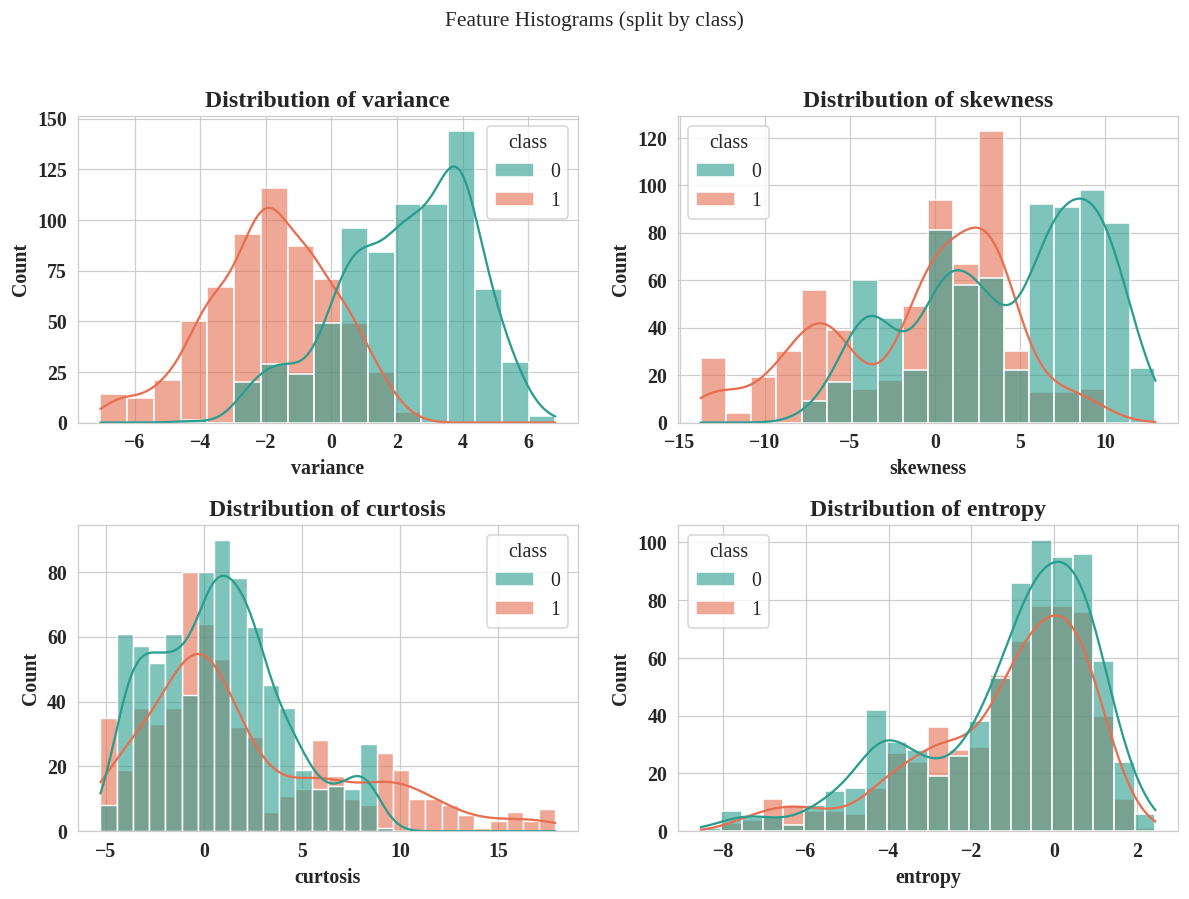

Saved figure: outputs/figures/task2_correlation_heatmap.eps  (35.8 KB)


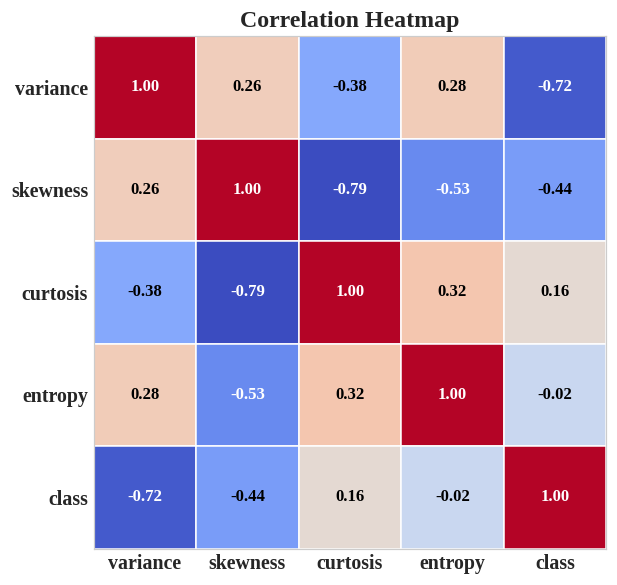

Saved figure: outputs/figures/task2_scatter_variance_skewness.eps  (205.4 KB)


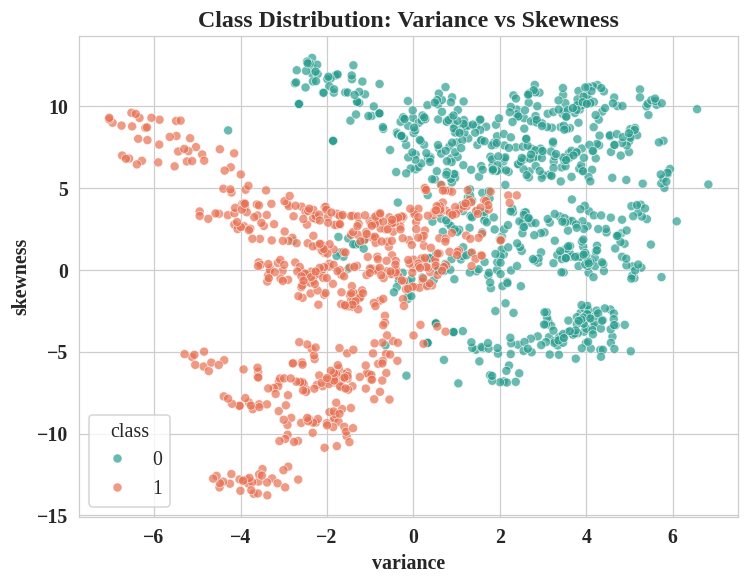

/tmp/ipykernel_2686/306674126.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=banknotes, x="class", y=col, ax=ax, palette=["#2a9d8f", "#e76f51"])
/tmp/ipykernel_2686/306674126.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=banknotes, x="class", y=col, ax=ax, palette=["#2a9d8f", "#e76f51"])
/tmp/ipykernel_2686/306674126.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=banknotes, x="class", y=col, ax=ax, palette=["#2a9d8f", "#e76f51"])
/tmp/ipykernel_2686/306674126.py:38: FutureWarning: 

Passing `palette` without

Saved figure: outputs/figures/task2_boxplots.eps  (46.8 KB)


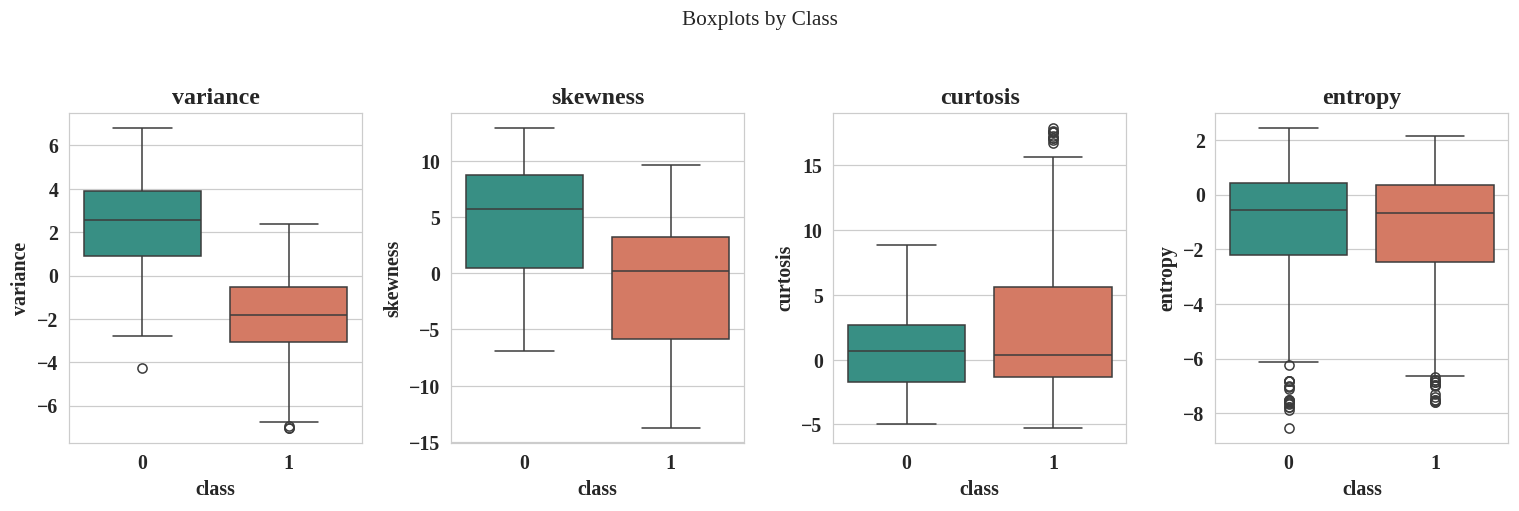

In [17]:
feature_cols = ["variance", "skewness", "curtosis", "entropy"]

# Histograms
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), feature_cols):
    sns.histplot(data=banknotes, x=col, hue="class", kde=True, ax=ax,
                 palette=["#2a9d8f", "#e76f51"], alpha=0.6)
    ax.set_title(f"Distribution of {col}")
fig.suptitle("Feature Histograms (split by class)", y=1.02, fontsize=14)
plt.tight_layout()
save_fig("task2_feature_histograms")
plt.show()

# Correlation heatmap (hand-drawn as vector rectangles, not sns.heatmap,
# to keep the saved .eps small at 600 DPI)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
corr_matrix = banknotes[feature_cols + ["class"]].corr()
corr_labels = corr_matrix.columns.tolist()
draw_vector_heatmap(ax, corr_matrix.to_numpy(), corr_labels, corr_labels,
                     annotate=True, cmap_name="coolwarm", fmt="{:.2f}")
plt.title("Correlation Heatmap")
plt.tight_layout()
save_fig("task2_correlation_heatmap")
plt.show()

# Scatter plot
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=banknotes, x="variance", y="skewness", hue="class",
                 palette=["#2a9d8f", "#e76f51"], alpha=0.7, s=35)
plt.title("Class Distribution: Variance vs Skewness")
plt.tight_layout()
save_fig("task2_scatter_variance_skewness")
plt.show()

# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
for ax, col in zip(axes, feature_cols):
    sns.boxplot(data=banknotes, x="class", y=col, ax=ax, palette=["#2a9d8f", "#e76f51"])
    ax.set_title(col)
fig.suptitle("Boxplots by Class", y=1.03, fontsize=14)
plt.tight_layout()
save_fig("task2_boxplots")
plt.show()


## Task 3 — Data Preprocessing

In [18]:
def zscore_normalize(matrix: np.ndarray, mean: np.ndarray = None, std: np.ndarray = None):
    # Standardize features to zero mean / unit variance.
    # If mean/std are not supplied, compute from `matrix` (fit mode);
    # otherwise apply the supplied stats (transform mode) to avoid leaking
    # test-set statistics into training.
    if mean is None:
        mean = matrix.mean(axis=0)
    if std is None:
        std = matrix.std(axis=0)
        std[std == 0] = 1e-8  # guard against zero-variance columns
    return (matrix - mean) / std, mean, std


def train_test_partition(X: np.ndarray, y: np.ndarray, test_fraction: float = 0.2, seed: int = RNG_SEED):
    # Manual shuffle-and-split (no sklearn) to keep the pipeline transparent.
    n_samples = X.shape[0]
    local_rng = np.random.default_rng(seed)
    shuffled_idx = local_rng.permutation(n_samples)

    n_test = int(np.floor(n_samples * test_fraction))
    test_idx, train_idx = shuffled_idx[:n_test], shuffled_idx[n_test:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_raw = banknotes[feature_cols].to_numpy(dtype=float)
y_raw = banknotes["class"].to_numpy(dtype=int)

X_train_raw, X_test_raw, y_train, y_test = train_test_partition(X_raw, y_raw, test_fraction=0.2)

# Fit normalization stats on TRAIN only, then apply to both splits
X_train, feat_mean, feat_std = zscore_normalize(X_train_raw)
X_test, _, _ = zscore_normalize(X_test_raw, mean=feat_mean, std=feat_std)

print("Train set:", X_train.shape, "| Test set:", X_test.shape)
print("Train class balance:", np.bincount(y_train))
print("Test class balance :", np.bincount(y_test))


Train set: (1098, 4) | Test set: (274, 4)
Train class balance: [613 485]
Test class balance : [149 125]


## Task 4 & 5 — Perceptron Implementation and Training

In [19]:
class RosenblattUnit:
    # Single-layer perceptron implementing Rosenblatt original learning
    # rule with the step activation function.
    #
    # After .fit():
    #   weight_history_ : list of weight vectors, one snapshot per epoch
    #   bias_history_   : list of bias values, one snapshot per epoch
    #   error_history_  : list of misclassified-sample counts, one per epoch

    def __init__(self, n_features: int, learning_rate: float = 0.01, n_epochs: int = 50, seed: int = RNG_SEED):
        local_rng = np.random.default_rng(seed)
        self.weights = local_rng.normal(loc=0.0, scale=0.01, size=n_features)
        self.bias = 0.0
        self.eta = learning_rate
        self.n_epochs = n_epochs

        self.weight_history_ = []
        self.bias_history_ = []
        self.error_history_ = []

    @staticmethod
    def _step(z: np.ndarray) -> np.ndarray:
        return np.where(z >= 0, 1, 0)

    def _forward(self, X: np.ndarray) -> np.ndarray:
        z = X @ self.weights + self.bias
        return self._step(z)

    def fit(self, X: np.ndarray, y: np.ndarray, verbose: bool = True):
        n_samples = X.shape[0]

        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0

            # Sample-by-sample (online) update:
            # w_new = w_old + eta * (y - y_hat) * x
            for i in range(n_samples):
                x_i = X[i]
                target = y[i]

                z_i = np.dot(self.weights, x_i) + self.bias
                pred = 1 if z_i >= 0 else 0

                error = target - pred
                if error != 0:
                    misclassified += 1
                    self.weights += self.eta * error * x_i
                    self.bias += self.eta * error

            self.weight_history_.append(self.weights.copy())
            self.bias_history_.append(self.bias)
            self.error_history_.append(misclassified)

            if verbose and (epoch <= 5 or epoch % 10 == 0 or misclassified == 0):
                print(f"Epoch {epoch:3d} | Misclassified: {misclassified:4d} | "
                      f"Bias: {self.bias:.4f} | ||w||: {np.linalg.norm(self.weights):.4f}")

            if misclassified == 0:
                if verbose:
                    print(f"\nConverged at epoch {epoch} — zero training errors.")
                break

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self._forward(X)


LEARNING_RATE = 0.01
N_EPOCHS = 50

perceptron = RosenblattUnit(n_features=X_train.shape[1], learning_rate=LEARNING_RATE, n_epochs=N_EPOCHS)
perceptron.fit(X_train, y_train, verbose=True)

print("\nFinal learned weights:", np.round(perceptron.weights, 4))
print("Final learned bias    :", round(perceptron.bias, 4))


Epoch   1 | Misclassified:   53 | Bias: -0.0300 | ||w||: 0.1064
Epoch   2 | Misclassified:   32 | Bias: -0.0500 | ||w||: 0.1425
Epoch   3 | Misclassified:   24 | Bias: -0.0500 | ||w||: 0.1650
Epoch   4 | Misclassified:   22 | Bias: -0.0500 | ||w||: 0.1785
Epoch   5 | Misclassified:   26 | Bias: -0.0500 | ||w||: 0.1941
Epoch  10 | Misclassified:   20 | Bias: -0.0600 | ||w||: 0.2321
Epoch  20 | Misclassified:   17 | Bias: -0.0800 | ||w||: 0.2782
Epoch  30 | Misclassified:   17 | Bias: -0.0900 | ||w||: 0.3136
Epoch  40 | Misclassified:   14 | Bias: -0.0900 | ||w||: 0.3399
Epoch  50 | Misclassified:   12 | Bias: -0.1000 | ||w||: 0.3613

Final learned weights: [-0.1931 -0.2132 -0.2176 -0.0217]
Final learned bias    : -0.1


## Task 6 — Model Evaluation

=== Test Set Performance ===
Accuracy  : 0.9781
Precision : 0.9837
Recall    : 0.9680
F1_score  : 0.9758
Confusion Matrix: {'TP': 121, 'TN': 147, 'FP': 2, 'FN': 4}
Saved figure: outputs/figures/task6_confusion_matrix.eps  (23.2 KB)


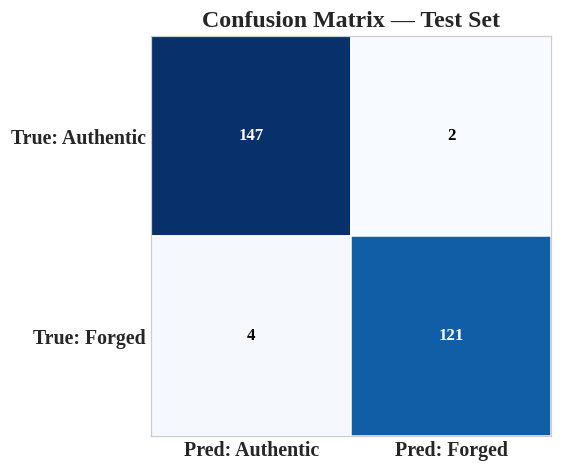

In [20]:
def confusion_counts(y_true: np.ndarray, y_pred: np.ndarray):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return tp, tn, fp, fn


def classification_report_manual(y_true: np.ndarray, y_pred: np.ndarray):
    tp, tn, fp, fn = confusion_counts(y_true, y_pred)

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": {"TP": tp, "TN": tn, "FP": fp, "FN": fn},
    }


y_pred_test = perceptron.predict(X_test)
metrics = classification_report_manual(y_test, y_pred_test)

print("=== Test Set Performance ===")
for key, val in metrics.items():
    if key == "confusion_matrix":
        print("Confusion Matrix:", val)
    else:
        print(f"{key.capitalize():10s}: {val:.4f}")

tp, tn, fp, fn = confusion_counts(y_test, y_pred_test)
cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4.5))
draw_vector_heatmap(ax, cm.astype(float),
                     row_labels=["True: Authentic", "True: Forged"],
                     col_labels=["Pred: Authentic", "Pred: Forged"],
                     annotate=True, cmap_name="Blues", fmt="{:.0f}")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
save_fig("task6_confusion_matrix")
plt.show()


## Mandatory Plots — Training Dynamics

Saved figure: outputs/figures/training_error_vs_epoch.eps  (25.4 KB)


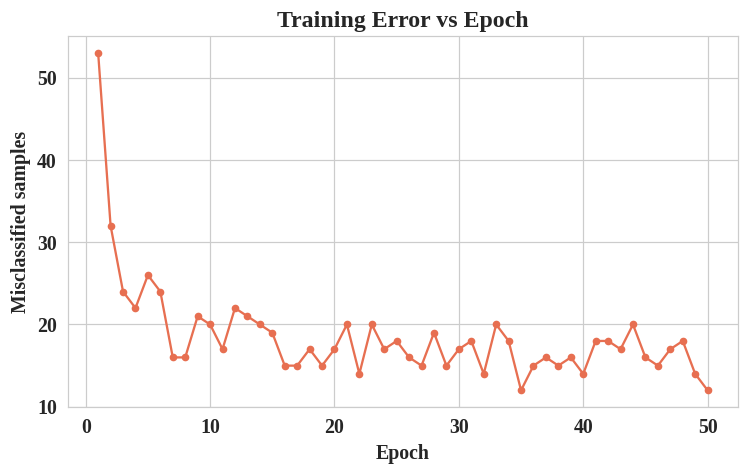

Saved figure: outputs/figures/weight_evolution.eps  (38.9 KB)


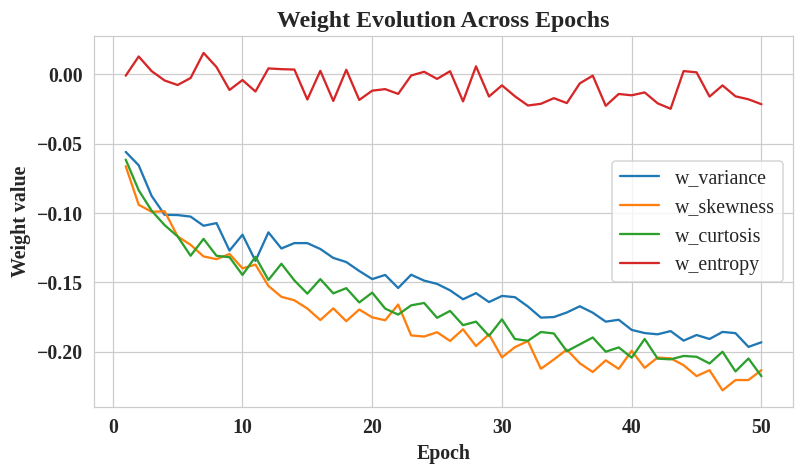

Saved figure: outputs/figures/bias_evolution.eps  (28.3 KB)


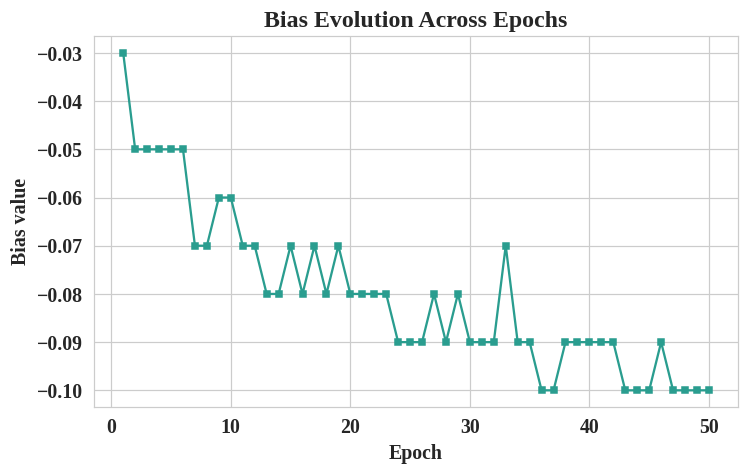

In [21]:
weight_hist = np.array(perceptron.weight_history_)

# Training error vs epoch
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(perceptron.error_history_) + 1), perceptron.error_history_,
         marker="o", color="#e76f51", linewidth=1.5, markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Misclassified samples")
plt.title("Training Error vs Epoch")
plt.tight_layout()
save_fig("training_error_vs_epoch")
plt.show()

# Weight evolution
plt.figure(figsize=(7.5, 4.5))
for idx, name in enumerate(feature_cols):
    plt.plot(range(1, len(weight_hist) + 1), weight_hist[:, idx], label=f"w_{name}")
plt.xlabel("Epoch")
plt.ylabel("Weight value")
plt.title("Weight Evolution Across Epochs")
plt.legend()
plt.tight_layout()
save_fig("weight_evolution")
plt.show()

# Bias evolution
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(perceptron.bias_history_) + 1), perceptron.bias_history_,
         color="#2a9d8f", marker="s", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Bias value")
plt.title("Bias Evolution Across Epochs")
plt.tight_layout()
save_fig("bias_evolution")
plt.show()


## Learning Rate Comparison (Task 7 / Additional Task 3)

Saved figure: outputs/figures/learning_rate_comparison.eps  (43.4 KB)


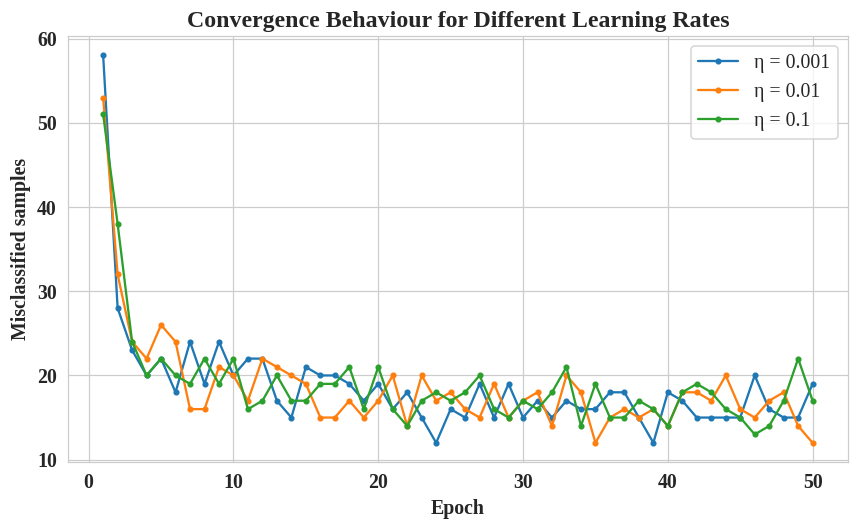

In [22]:
learning_rates_to_test = [0.001, 0.01, 0.1]
lr_results = {}

for lr in learning_rates_to_test:
    model = RosenblattUnit(n_features=X_train.shape[1], learning_rate=lr, n_epochs=N_EPOCHS, seed=RNG_SEED)
    model.fit(X_train, y_train, verbose=False)
    lr_results[lr] = model.error_history_

plt.figure(figsize=(8, 5))
for lr, err_hist in lr_results.items():
    plt.plot(range(1, len(err_hist) + 1), err_hist, marker="o", markersize=3, label=f"η = {lr}")
plt.xlabel("Epoch")
plt.ylabel("Misclassified samples")
plt.title("Convergence Behaviour for Different Learning Rates")
plt.legend()
plt.tight_layout()
save_fig("learning_rate_comparison")
plt.show()


## Decision Boundary Visualization (Optional)

Saved figure: outputs/figures/decision_boundary.eps  (314.7 KB)


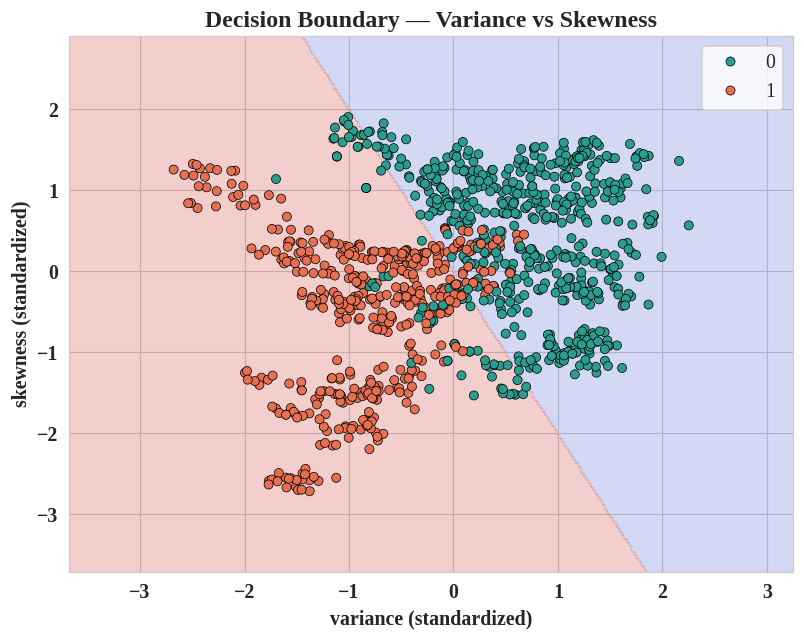

In [23]:
X2_train = X_train[:, [0, 1]]
X2_test = X_test[:, [0, 1]]

model_2d = RosenblattUnit(n_features=2, learning_rate=LEARNING_RATE, n_epochs=N_EPOCHS)
model_2d.fit(X2_train, y_train, verbose=False)

x_min, x_max = X2_train[:, 0].min() - 1, X2_train[:, 0].max() + 1
y_min, y_max = X2_train[:, 1].min() - 1, X2_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_preds = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7.5, 6))
plt.contourf(xx, yy, grid_preds, alpha=0.25, cmap="coolwarm")
sns.scatterplot(x=X2_train[:, 0], y=X2_train[:, 1], hue=y_train,
                 palette=["#2a9d8f", "#e76f51"], edgecolor="k", s=35)
plt.xlabel("variance (standardized)")
plt.ylabel("skewness (standardized)")
plt.title("Decision Boundary — Variance vs Skewness")
plt.tight_layout()
save_fig("decision_boundary")
plt.show()


## Additional Task 2 — Comparison with Scikit-learn's Perceptron

In [24]:
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sk_model = SklearnPerceptron(eta0=LEARNING_RATE, max_iter=N_EPOCHS, random_state=RNG_SEED, tol=1e-3)
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Custom RosenblattUnit": [
        metrics["accuracy"], metrics["precision"], metrics["recall"], metrics["f1_score"]
    ],
    "sklearn.Perceptron": [
        accuracy_score(y_test, sk_pred),
        precision_score(y_test, sk_pred),
        recall_score(y_test, sk_pred),
        f1_score(y_test, sk_pred),
    ],
})
display(comparison_table)


,Metric,Custom RosenblattUnit,sklearn.Perceptron
0,Accuracy,0.978102,0.978102
1,Precision,0.983740,0.976000
2,Recall,0.968000,0.976000
3,F1-score,0.975806,0.976000


## Additional Task 1 — Step vs Sigmoid Activation

Saved figure: outputs/figures/step_vs_sigmoid_activation.eps  (30.2 KB)


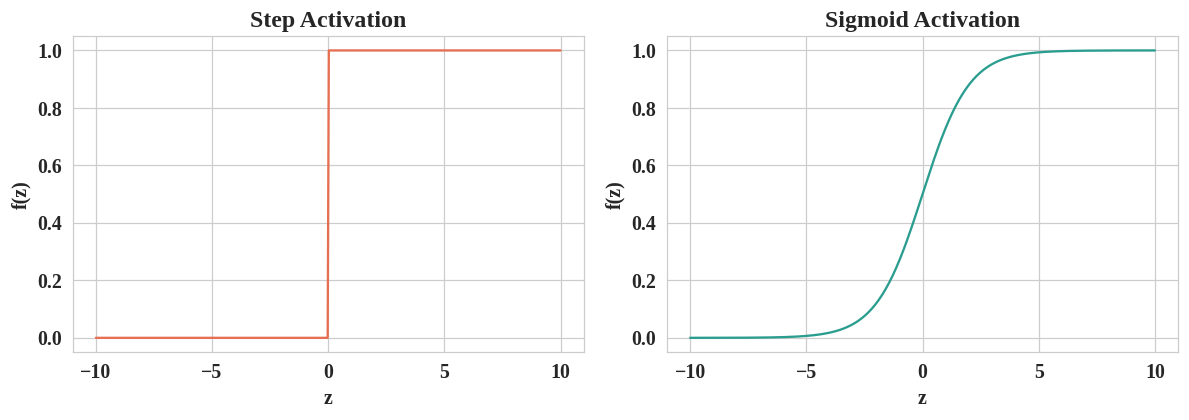

In [25]:
z_vals = np.linspace(-10, 10, 400)
step_vals = np.where(z_vals >= 0, 1, 0)
sigmoid_vals = 1 / (1 + np.exp(-z_vals))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(z_vals, step_vals, color="#e76f51")
axes[0].set_title("Step Activation")
axes[0].set_xlabel("z"); axes[0].set_ylabel("f(z)")

axes[1].plot(z_vals, sigmoid_vals, color="#2a9d8f")
axes[1].set_title("Sigmoid Activation")
axes[1].set_xlabel("z"); axes[1].set_ylabel("f(z)")

plt.tight_layout()
save_fig("step_vs_sigmoid_activation", fig=fig)
plt.show()


## Additional Task 4 — Why a Single-Layer Perceptron Cannot Solve XOR

Final misclassified count on XOR (out of 4 samples): 4
Saved figure: outputs/figures/xor_not_linearly_separable.eps  (25.3 KB)


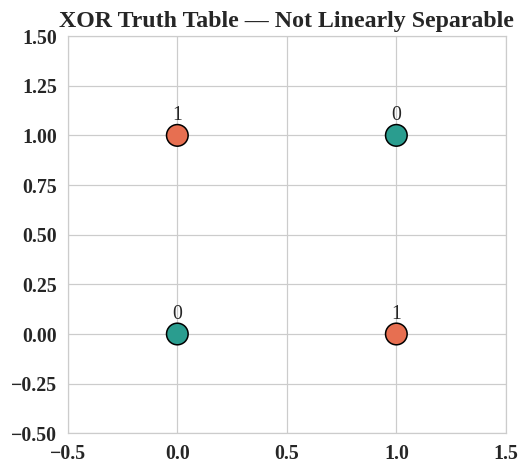

In [26]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

xor_model = RosenblattUnit(n_features=2, learning_rate=0.1, n_epochs=100)
xor_model.fit(X_xor, y_xor, verbose=False)

print("Final misclassified count on XOR (out of 4 samples):", xor_model.error_history_[-1])

plt.figure(figsize=(5, 4.5))
colors = ["#e76f51" if label == 1 else "#2a9d8f" for label in y_xor]
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200, edgecolor="k")
for (x, y), label in zip(X_xor, y_xor):
    plt.annotate(str(label), (x, y), textcoords="offset points", xytext=(0, 10), ha="center")
plt.title("XOR Truth Table — Not Linearly Separable")
plt.xlim(-0.5, 1.5); plt.ylim(-0.5, 1.5)
plt.tight_layout()
save_fig("xor_not_linearly_separable")
plt.show()


## Additional Task 5 — Effect of Feature Normalization on Convergence

Saved figure: outputs/figures/normalization_effect_on_convergence.eps  (48.2 KB)


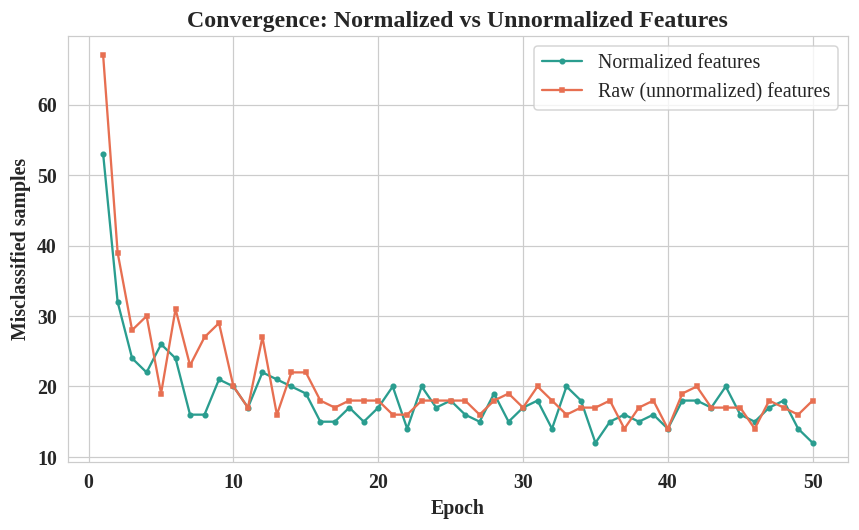

In [27]:
model_normalized = RosenblattUnit(n_features=X_train.shape[1], learning_rate=LEARNING_RATE, n_epochs=N_EPOCHS)
model_normalized.fit(X_train, y_train, verbose=False)

model_unnormalized = RosenblattUnit(n_features=X_train_raw.shape[1], learning_rate=LEARNING_RATE, n_epochs=N_EPOCHS)
model_unnormalized.fit(X_train_raw, y_train, verbose=False)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(model_normalized.error_history_) + 1), model_normalized.error_history_,
         marker="o", markersize=3, label="Normalized features", color="#2a9d8f")
plt.plot(range(1, len(model_unnormalized.error_history_) + 1), model_unnormalized.error_history_,
         marker="s", markersize=3, label="Raw (unnormalized) features", color="#e76f51")
plt.xlabel("Epoch")
plt.ylabel("Misclassified samples")
plt.title("Convergence: Normalized vs Unnormalized Features")
plt.legend()
plt.tight_layout()
save_fig("normalization_effect_on_convergence")
plt.show()


## Section 8 — Performance Tables

In [28]:
training_summary = pd.DataFrame({
    "Item": ["Dataset Size", "Train/Test Split", "Learning Rate", "Epochs (ran/max)",
             "Final Weights", "Final Bias", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [
        len(banknotes),
        f"{len(X_train)} / {len(X_test)}  (80/20)",
        LEARNING_RATE,
        f"{len(perceptron.error_history_)} / {N_EPOCHS}",
        np.round(perceptron.weights, 4).tolist(),
        round(perceptron.bias, 4),
        round(metrics["accuracy"], 4),
        round(metrics["precision"], 4),
        round(metrics["recall"], 4),
        round(metrics["f1_score"], 4),
    ],
})
display(training_summary)

epoch_table = pd.DataFrame({
    "Epoch": range(1, len(perceptron.error_history_) + 1),
    "Errors": perceptron.error_history_,
    "Weight_variance": weight_hist[:, 0],
    "Weight_skewness": weight_hist[:, 1],
    "Bias": perceptron.bias_history_,
})
display(epoch_table.head(10))

Path("outputs").mkdir(exist_ok=True)
training_summary.to_csv("outputs/training_summary.csv", index=False)
epoch_table.to_csv("outputs/epoch_wise_learning.csv", index=False)
comparison_table.to_csv("outputs/sklearn_comparison.csv", index=False)
print("Saved: outputs/training_summary.csv, outputs/epoch_wise_learning.csv, outputs/sklearn_comparison.csv")
print(f"All plots saved as .eps in: {FIGURES_DIR.resolve()}")


,Item,Value
0,Dataset Size,1372
1,Train/Test Split,1098 / 274 (80/20)
2,Learning Rate,0.01
3,Epochs (ran/max),50 / 50
4,Final Weights,"[-0.1931, -0.2132, -0.2176, -0.0217]"
5,Final Bias,-0.1
6,Accuracy,0.9781
7,Precision,0.9837
8,Recall,0.968
9,F1-score,0.9758


,Epoch,Errors,Weight_variance,Weight_skewness,Bias
0,1,53,-0.056001,-0.066295,-0.03
1,2,32,-0.065651,-0.094079,-0.05
2,3,24,-0.087762,-0.099122,-0.05
3,4,22,-0.101298,-0.098768,-0.05
4,5,26,-0.101496,-0.116839,-0.05
5,6,24,-0.102593,-0.122935,-0.05
6,7,16,-0.109190,-0.131280,-0.07
7,8,16,-0.107278,-0.133245,-0.07
8,9,21,-0.127082,-0.129512,-0.06
9,10,20,-0.115651,-0.139847,-0.06


Saved: outputs/training_summary.csv, outputs/epoch_wise_learning.csv, outputs/sklearn_comparison.csv
All plots saved as .eps in: /content/outputs/figures
